# ENTENDIMIENTO DE LOS DATOS




### Librerias

In [7]:
#Importar librerías

import pandas as pd
import openpyxl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_pacf, plot_acf, quarter_plot, month_plot

## Series de tiempo forma Discreta

### Carga de Datos:

Para la carga de datos desde .xlsx eliminar los comentarios,
Para la carga de datos desde .csv solo correr el codigo

In [8]:
#Cargar los datos (no se puede hacer directamente con pandas)
"""
def leer_datos_consumo(archivo, hoja):


    # Cargar el workbook con openpyxl para manejar celdas fusionadas
    wb = openpyxl.load_workbook(archivo, data_only=True)
    ws = wb[hoja]

    # La tabla comienza en la fila 16 (encabezados) y 17 (datos)
    fila_inicio_datos = 17

    # Leer datos fila por fila
    datos = []

    for fila in range(fila_inicio_datos, ws.max_row + 1):
        # La fecha está en la columna B (columna 2), pero fusionada en B:D
        fecha = ws.cell(row=fila, column=2).value

        # Si no hay fecha, hemos llegado al final de los datos
        if fecha is None or not isinstance(fecha, str):
            break

        # Leer las 24 horas de consumo
        fila_datos = {'Fecha': fecha}

        # Mapeo de las columnas de horas
        columnas_horas = [
            5,   # H1 (E)
            7,   # H2 (G)
            8,   # H3 (H)
            9,   # H4 (I)
            12,  # H5 (L)
            14,  # H6 (N)
            16,  # H7 (P)
            21,  # H8 (U)
            22,  # H9 (V)
            23,  # H10 (W)
            24,  # H11 (X)
            25,  # H12 (Y)
            26,  # H13 (Z)
            27,  # H14 (AA)
            28,  # H15 (AB)
            29,  # H16 (AC)
            30,  # H17 (AD)
            31,  # H18 (AE)
            32,  # H19 (AF)
            33,  # H20 (AG)
            34,  # H21 (AH)
            35,  # H22 (AI)
            36,  # H23 (AJ)
            37,  # H24 (AK)
        ]

        # Leer cada hora
        for i, col in enumerate(columnas_horas, 1):
            valor = ws.cell(row=fila, column=col).value
            fila_datos[f'H{i}'] = valor  # Si es None, queda None

        # La columna total está en AL (38)
        total = ws.cell(row=fila, column=38).value
        fila_datos['Total'] = total  # Si es None, queda None

        datos.append(fila_datos)

    # Crear DataFrame
    df = pd.DataFrame(datos)

    # Convertir fecha a datetime
    df['Fecha'] = pd.to_datetime(df['Fecha'], format='%d/%m/%Y')

    # Asegurar que las columnas de consumo sean numéricas
    columnas_numericas = [f'H{i}' for i in range(1, 25)] + ['Total']
    for col in columnas_numericas:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    wb.close()

    return df


archivo1 = 'Consumos 2018-2020.xlsx'
archivo2 = 'Consumos 2023-2024.xlsx'
archivo3 = 'Consumos 2021-2022.xlsx'
archivo4 = 'Consumos 2025.xlsx'


#Leer las tres hojas con los consumos de las plantas (ENVIGADO, SAN DIEGO, ZAMORA) en todos los intervalos de tiempo
df_env1 = leer_datos_consumo(archivo1, 'METRO_ENV')
df_env2 = leer_datos_consumo(archivo2, 'METRO_ENV')
df_env3 = leer_datos_consumo(archivo3, 'METRO_ENV')
df_env4 = leer_datos_consumo(archivo4, 'METRO_ENV')

df_zamo1 = leer_datos_consumo(archivo1, 'METRO_ZAMO')
df_zamo2 = leer_datos_consumo(archivo2, 'METRO_ZAMO')
df_zamo3 = leer_datos_consumo(archivo3, 'METRO_ZAMO')
df_zamo4 = leer_datos_consumo(archivo4, 'METRO_ZAMO')

df_sand1 = leer_datos_consumo(archivo1, 'METRO_SAND')
df_sand2 = leer_datos_consumo(archivo2, 'METRO_SAND')
df_sand3 = leer_datos_consumo(archivo3, 'METRO_SAND')
df_sand4 = leer_datos_consumo(archivo4, 'METRO_SAND')

#Importar Serie


#Concatenar los dataframes

df_env = pd.concat([df_env1, df_env2, df_env3, df_env4], ignore_index=True)
df_zamo = pd.concat([df_zamo1, df_zamo2, df_zamo3, df_zamo4], ignore_index=True)
df_sand = pd.concat([df_sand1, df_sand2, df_sand3, df_sand4], ignore_index=True)"""

#df_env = df_env.sort_values("Fecha").reset_index(drop=True)
#df_sand = df_sand.sort_values("Fecha").reset_index(drop=True)
#df_zamo = df_zamo.sort_values("Fecha").reset_index(drop=True)



df_env = pd.read_csv("datos/dataframe_envigado.csv", index_col=0)
df_zamo = pd.read_csv("datos/dataframe_zamora.csv", index_col=0)
df_sand = pd.read_csv("datos/dataframe_sandiego.csv", index_col=0)


df_env = df_env.sort_values("Fecha").reset_index(drop=True)
df_sand = df_sand.sort_values("Fecha").reset_index(drop=True)
df_zamo = df_zamo.sort_values("Fecha").reset_index(drop=True)

df_env["Fecha"] = pd.to_datetime(df_env["Fecha"])
df_sand["Fecha"] = pd.to_datetime(df_sand["Fecha"])
df_zamo["Fecha"] = pd.to_datetime(df_zamo["Fecha"])


### Entendimiento:

In [9]:
# Ver la serie
df_zamo

,Fecha,H1,H2,H3,H4,H5,H6,H7,H8,H9,...,H16,H17,H18,H19,H20,H21,H22,H23,H24,Total
0,2018-01-01,718.6672,726.0006,718.6671,722.3338,722.3336,1257.6672,2559.3338,2478.6671,2508.0003,...,2680.3339,2603.3339,2874.6674,2962.6673,2680.3341,2867.3341,2654.6676,2321.0008,861.6671,50072.0140
1,2018-01-02,832.3338,777.3338,810.3338,920.3338,2970.0008,4528.3341,5166.3346,5049.0013,4326.6678,...,4935.3346,5544.0011,5863.0014,5654.0013,4693.3343,4242.3345,3582.3343,3487.0009,2086.3339,90577.6890
2,2018-01-03,986.3338,1008.3339,993.6673,1008.3338,3208.3341,4902.3343,5551.3344,5408.3346,4777.6679,...,5016.0011,5247.0014,5808.0013,5665.0014,4891.3346,3813.3343,3487.0008,3215.6674,2053.3338,93408.3559
3,2018-01-04,1034.0003,927.6670,942.3338,975.3335,3028.6675,4664.0011,5195.6681,5335.0014,4730.0011,...,4818.0008,5276.3343,5844.6681,5679.6681,5016.0014,4125.0009,3483.3339,3300.0008,1936.0003,92077.3555
4,2018-01-05,1015.6671,971.6673,971.6671,924.0005,3058.0006,4700.6679,5320.3348,5404.6678,4689.6678,...,4682.3341,5408.3349,5386.3343,5804.3349,5228.6679,3967.3343,3384.3339,3102.0009,2123.0006,92524.6893
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2917,2025-12-27,1048.4252,1072.6240,1038.3540,1261.3060,3859.8112,4967.5760,5139.8660,5285.2100,4534.5720,...,5592.8552,5434.5340,5012.5620,4710.2492,4520.7272,4157.9312,3559.5120,3482.9400,2020.0012,95642.0544
2918,2025-12-28,1086.3792,1029.1340,1035.1312,1123.8720,1731.3452,3056.3592,2988.6032,3044.8972,3077.7600,...,3564.3872,3484.0432,3623.0340,3961.4012,3719.0812,3600.3460,3607.8352,2928.2352,1413.9092,68599.0984
2919,2025-12-29,1184.4992,1223.1612,1259.8852,1455.7592,3994.7812,5112.1020,5219.7492,5311.8072,5023.0000,...,5356.6700,5583.9332,5958.6440,6057.6420,5309.6800,4388.7860,3861.7300,3462.4520,2187.9192,97647.7940
2920,2025-12-30,1144.8140,1082.1220,1033.8132,1071.4752,3757.8952,4720.9172,4967.6592,4910.3080,4659.4612,...,5478.1300,5372.2872,5615.5800,5933.3340,5276.4772,4193.7380,3813.8412,3195.4340,2072.6852,93933.1248


In [10]:
#Ver la información de cada columna del dataset (ENVIGADO)
df_zamo.info()

<class 'pandas.DataFrame'>
RangeIndex: 2922 entries, 0 to 2921
Data columns (total 26 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Fecha   2922 non-null   datetime64[us]
 1   H1      2922 non-null   float64       
 2   H2      2922 non-null   float64       
 3   H3      2922 non-null   float64       
 4   H4      2922 non-null   float64       
 5   H5      2922 non-null   float64       
 6   H6      2922 non-null   float64       
 7   H7      2922 non-null   float64       
 8   H8      2922 non-null   float64       
 9   H9      2922 non-null   float64       
 10  H10     2922 non-null   float64       
 11  H11     2922 non-null   float64       
 12  H12     2922 non-null   float64       
 13  H13     2922 non-null   float64       
 14  H14     2922 non-null   float64       
 15  H15     2922 non-null   float64       
 16  H16     2922 non-null   float64       
 17  H17     2922 non-null   float64       
 18  H18     2922 non-nu

In [11]:
#Ver estadísticas descriptivas del dataset (ENVIGADO)
df_zamo.describe()

,Fecha,H1,H2,H3,H4,H5,H6,H7,H8,H9,...,H16,H17,H18,H19,H20,H21,H22,H23,H24,Total
count,2922,2922.000000,2922.000000,2922.000000,2922.000000,2922.000000,2922.000000,2922.000000,2922.000000,2922.000000,...,2922.000000,2922.000000,2922.000000,2922.000000,2922.000000,2922.000000,2922.000000,2922.000000,2922.000000,2922.000000
mean,2021-12-31 12:00:00,1124.975598,1068.701384,1071.550084,1205.977573,3411.355308,5257.155095,5682.224294,5490.952706,4874.289021,...,5175.722732,5587.112117,5843.545284,5797.183346,5253.283913,4442.940697,3873.518412,3447.734393,2077.869174,96492.090332
min,2018-01-01 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,55.000400
25%,2020-01-01 06:00:00,1008.333700,982.667100,990.000600,1114.667000,3208.334025,4766.667350,5104.000875,4991.251225,4345.000675,...,4774.001175,4983.917600,4965.584725,4829.483750,4425.667225,3934.334000,3575.001125,3050.666875,1540.000300,88163.179225
50%,2021-12-31 12:00:00,1122.000100,1096.910000,1100.000000,1232.000100,3675.834150,5654.001250,6255.334050,6022.501100,5247.001300,...,5503.667700,6037.167900,6284.667700,6216.834900,5586.167600,4581.500900,3883.000800,3468.667300,2148.666800,101667.521150
75%,2023-12-31 18:00:00,1239.333975,1199.000000,1199.000000,1349.333500,4026.402300,6089.417450,6644.001475,6416.668200,5627.417200,...,5819.001275,6503.750825,6966.668000,6918.084400,6112.335025,5001.334475,4312.000550,3937.083775,2521.750475,109488.520475
max,2025-12-31 00:00:00,3468.667500,3245.000300,2306.333600,2218.333900,5324.000800,8473.668800,9251.002300,9005.336400,8015.334400,...,7956.668700,8983.335900,9731.334800,9606.667900,8543.335900,6878.667500,5892.334100,5225.000600,4139.500000,147253.352800
std,NaN,310.717086,261.324400,237.712762,239.803781,920.297015,1291.092593,1465.473396,1415.737844,1099.573510,...,1088.668296,1325.982353,1488.211137,1455.614744,1217.328660,891.223175,719.857294,711.165008,675.746991,19224.989042


Entendimiento pre-analisis (En general para los tres conjuntos de datos), se observa:

* Se observa que entre las [H1, H5], el consumo fue bastante disminuido, por debajo de 1.000 kw (en promedio)

* Las desviaciones estandar entre las horas [H6, H20], son bastante elevadas, por encima de 1.000, lo que significa que son bastante impredecibles durante este intervalo de tiempo.

* Los valores minimos en todos los conjuntos de datos son 0.0, lo que da idea de que hay demasiadas fluctuaciones en cualquier hora, implicando fallas en los medidores de consumo o dias donde de uso nulo en las estaciones

* Hay exactamente 1096 datos para los 1096 dias

### Dimensiones de calidad

#### Completitud

In [12]:
# Columnas horarias
cols_horas = [f'H{i}' for i in range(1,25)]
# Se crea la lista de fechas deberia de comprender la columna 'Fecha'
rango_fechas = pd.date_range(
    start=df_zamo['Fecha'].min(),
    end=df_zamo['Fecha'].max(),
    freq='D'
)

#Se comparan las fechas que deberían de existir en en dataset con las que de verdad hay
fechas_faltantes = rango_fechas.difference(df_zamo['Fecha'])

print("Días faltantes:", len(fechas_faltantes))


Días faltantes: 0


#### Conformidad o validez

In [13]:
negativos = (df_zamo[cols_horas] < 0).sum().sum()

print("Cantidad de registros negativos:", negativos)

Cantidad de registros negativos: 0


#### Consistencia

Se verifica la columna 'Total' como la suma de todas las horas. 

Se nota que esta suma tiene una cota inferior de practicamente 0. (Puede ser por temas de calculo de python o decimales)

In [14]:
df_zamo['suma_horas'] = df_zamo[cols_horas].sum(axis=1)

df_zamo['error_total'] = df_zamo['Total'] - df_zamo['suma_horas']

inconsistentes = df_zamo[np.abs(df_zamo['error_total']) > 1e-8]

print("Días inconsistentes:", len(inconsistentes))

df_zamo = df_zamo.drop(columns=['suma_horas', 'error_total'])

Días inconsistentes: 0


Se pone a interes el verificar si en una hora $H_t$ hay un consumo 'cota' tal que en la siguiente hora $H_{t+1}$ es nulo.

Estos casos pueden ser fallas, mantenimientos o cortos no previstos.

No necesariamente tiene que ser un error en los datos, sin embargo, si es un interes particular que puede ser para observar

#### Presición

In [15]:
#Precisión/Exactitud
cota = 100

df_prueba = df_zamo.copy()

horas = [f"H{i}" for i in range(1, 25)]

mask = pd.Series(False, index=df_prueba.index)

for i in range(len(horas)-1):
    col_actual = horas[i]
    col_siguiente = horas[i+1]
    mask |= (df_prueba[col_actual] > cota) & (df_prueba[col_siguiente] == 0)

# Filtramos las filas que cumplen la condición
df_filtrado = df_prueba[mask]

print("Registros con posibilidad de cortos con una cota inferior de:", cota, 'son:', len(df_filtrado))

df_filtrado.head()


Registros con posibilidad de cortos con una cota inferior de: 100 son: 11


,Fecha,H1,H2,H3,H4,H5,H6,H7,H8,H9,...,H16,H17,H18,H19,H20,H21,H22,H23,H24,Total
684,2019-11-16,517.0000,0.0,0.0,0.0,0.0000,0.0000,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,517.0000
755,2020-01-26,271.3335,0.0,0.0,0.0,0.0000,0.0000,0.0000,0.0000,0.0000,...,29.3332,25.6667,25.6667,29.3332,25.6667,25.6667,25.6667,29.3332,29.3334,579.3335
888,2020-06-07,366.6672,0.0,0.0,0.0,0.0000,0.0000,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,733.3340,1466.6684
909,2020-06-28,154.0000,0.0,0.0,11.0,14.6672,14.6672,14.6672,14.6672,14.6672,...,14.6672,14.6672,14.6672,14.6672,14.6672,18.3332,14.6672,14.6672,14.6672,462.0100
937,2020-07-26,733.3340,0.0,0.0,0.0,0.0000,0.0000,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,366.6672,0.0000,0.0000,0.0000,1100.0012


#### Duplicidad 

Dado que en completitud se tienen un total de registros por el total de dias de las series, quiere decir que los datos son completos y no duplicados

#### Integridad

No necesario por verificar, normalmente seria para varias bases de datos relacionadas

### Deteccion de Outliers

#### Metodos Univariados

##### Metodo Boxplot / Cuantiles

In [16]:
outliers_iqr_hora = {}

for col in cols_horas:

    Q1 = df_zamo[col].quantile(0.25)
    Q3 = df_zamo[col].quantile(0.75)
    IQR = Q3 - Q1

    lim_inf = Q1 - 1.5 * IQR
    lim_sup = Q3 + 1.5 * IQR

    mask = (df_zamo[col] < lim_inf) | (df_zamo[col] > lim_sup)

    outliers_iqr_hora[col] = mask.sum()

outliers_iqr_hora = pd.Series(outliers_iqr_hora)


print("\nTotal de outliers por metodo BoxPlot:", outliers_iqr_hora.sum())


Total de outliers por metodo BoxPlot: 2921


##### Metodo z-score

In [17]:
outliers_z_hora = {}

for col in cols_horas:

    mean = df_zamo[col].mean()
    std = df_zamo[col].std()

    z_scores = (df_zamo[col] - mean) / std

    mask = np.abs(z_scores) > 3

    outliers_z_hora[col] = mask.sum()

outliers_z_hora = pd.Series(outliers_z_hora)


print("\nTotal de outliers por metodo Z-score:", outliers_z_hora.sum())


Total de outliers por metodo Z-score: 860


##### Metodo Percentiles

In [18]:
outliers_pct_hora = {}

for col in cols_horas:

    p1 = df_zamo[col].quantile(0.01)
    p99 = df_zamo[col].quantile(0.99)

    mask = (df_zamo[col] < p1) | (df_zamo[col] > p99)

    outliers_pct_hora[col] = mask.sum()

outliers_pct_hora = pd.Series(outliers_pct_hora)


print("\nTotal de outliers por metodo Percentil:", outliers_pct_hora.sum())



Total de outliers por metodo Percentil: 1430


#### Metodo multivariado

Pendiente de integracion con todas las Series de tiempo

### Importancia de variables:

Consultar como funciona y ver si se puede hacer

### Escalamiento de variables:

Consultar como funciona y ver si se puede hacer

## Series de tiempo forma Continua

### Funcion para transformar los datos en forma continua

In [19]:
#Poner los datos de forma continua

def datos_continuos(
    df,
    fecha_col="Fecha",
    prefix_horas="H",
    n_horas=24
):
    """
    Convierte un dataframe en formato ancho (H1…H24) a serie de tiempo horaria.

    Parámetros
    ----------
    df : pandas.DataFrame
        Dataset original.

    fecha_col : str
        Nombre de la columna de fecha.

    prefix_horas : str
        Prefijo de las columnas horarias (en nuestro caso 'H').

    n_horas : int
        Número de horas (default 24).

    """

    df = df.copy()

    # --- 1. Fecha a datetime ---
    df[fecha_col] = pd.to_datetime(df[fecha_col])

    # --- 2. Columnas horarias ---
    cols_horas = [f"{prefix_horas}{i}" for i in range(1, n_horas + 1)]

    df_horas = df[[fecha_col] + cols_horas]

    # - Wide → Long ---
    df_long = df_horas.melt(
        id_vars=fecha_col,
        value_vars=cols_horas,
        var_name="Hora",
        value_name="Consumo"
    )

    # --- 4. Extraer hora numérica ---
    df_long["Hora"] = (
        df_long["Hora"].str.replace(prefix_horas, "", regex=False).astype(int)
    )

    # --- 5. Ajustar hora (H1 = 00:00) ---
    df_long["Hora"] = df_long["Hora"] - 1

    # --- 6. Crear datetime ---
    df_long["Datetime"] = (
        df_long[fecha_col] + pd.to_timedelta(df_long["Hora"], unit="h")
    )

    # --- 7. Indexar con la fecha + hora ---
    serie = (
        df_long.set_index("Datetime")["Consumo"].sort_index()
    )

    return serie

### Aplicar funcion a los datos

In [20]:
serie_envigado = datos_continuos(df_env)
serie_zamora = datos_continuos(df_zamo)
serie_sandiego = datos_continuos(df_sand)

Datos de interes primera vista:

In [21]:
serie_zamora

Datetime
2018-01-01 00:00:00     718.6672
2018-01-01 01:00:00     726.0006
2018-01-01 02:00:00     718.6671
2018-01-01 03:00:00     722.3338
2018-01-01 04:00:00     722.3336
                         ...    
2025-12-31 19:00:00    3779.7832
2025-12-31 20:00:00    3532.0972
2025-12-31 21:00:00    3434.5092
2025-12-31 22:00:00    2042.3952
2025-12-31 23:00:00    1107.4760
Name: Consumo, Length: 70128, dtype: float64

### Visualización por un criterio X

#### Visualizacion por hora

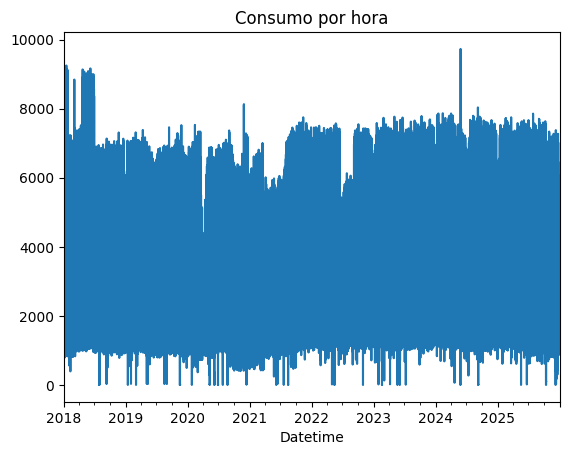

In [22]:
#Visualización por hora
serie_zamora.plot(title = 'Consumo por hora')
plt.show()

#### Visualizacion por dia

<Axes: title={'center': 'Consumo diario Zamora'}, xlabel='Datetime'>

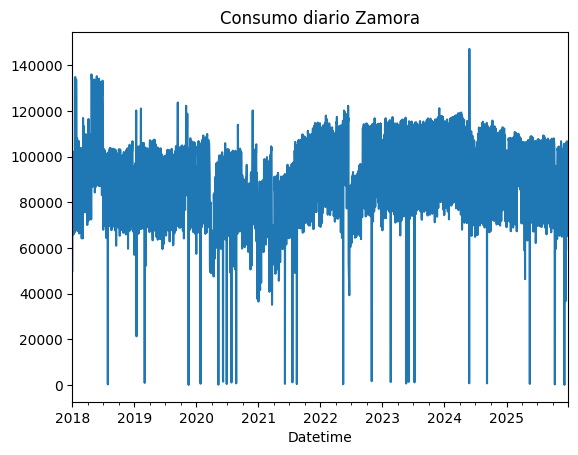

In [23]:
#Visualización de los datos por día
consumo_diario_zamora = serie_zamora.resample('D').sum()
consumo_diario_zamora.plot(title = 'Consumo diario Zamora')

#### Visualizacion por dia de un Mes & Year en particular

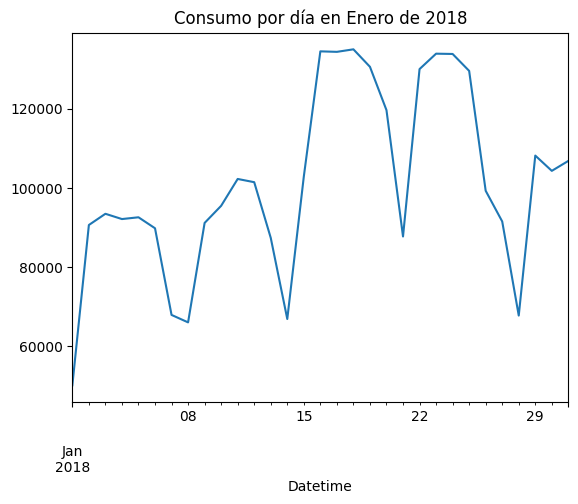

In [24]:
#Visualizar por hora durante un mes particular (enero)
consumo_diario_zamora.loc[(consumo_diario_zamora.index.month == 1) & (consumo_diario_zamora.index.year == 2018)].plot(title = 'Consumo por día en Enero de 2018')
plt.show()

#### Visualización de los datos por semana

<Axes: title={'center': 'Consumo Promedio por semana'}, xlabel='Datetime'>

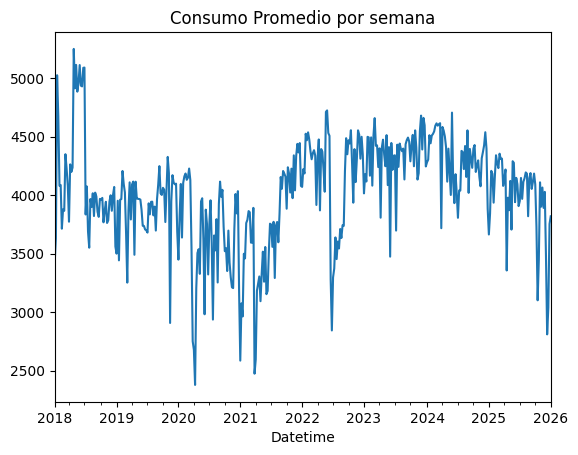

In [25]:
consumo_semanal_zamora = serie_zamora.resample('W').mean()
consumo_semanal_zamora.plot(title = 'Consumo Promedio por semana')

#### Demas prefijos para otras visualizaciones de interes

Existen diferentes ventanas temporales:

* B = día hábil

* D = día calendario

* W = semanal

* M = fin de mes

* BM = fin de mes hábil

* MS = inicio de mes

* BMS = inicio de mes hábil

* Q = fin de trimestre

* BQ = fin de trimestre hábil

* QS = inicio de trimestre

* BQS = inicio de trimestre hábil

* A = fin de año

* BA = fin de año hábil

* AS = inicio de año

* BAS = inicio de año hábil

* h = por hora

* min = por minuto

* s = por segundo

* ms = milisegundos

* us = microsegundos



### Analisis de interes

#### Visualizacion BoxPlot para cada hora

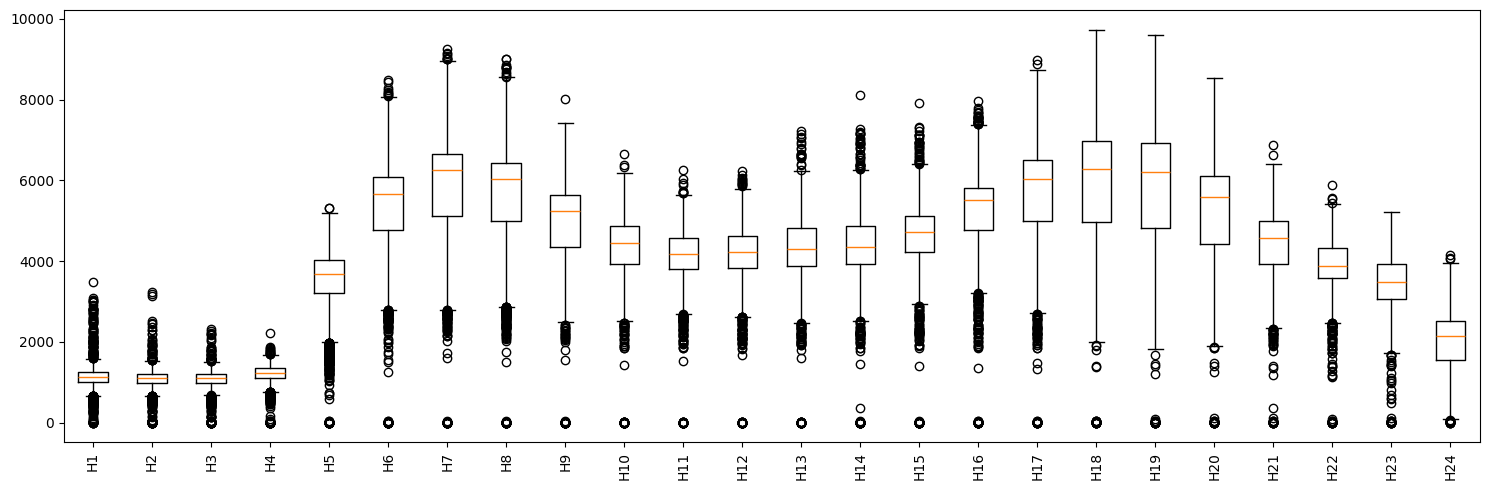

In [26]:
cols_horas = [f'H{i}' for i in range(1,25)]

plt.figure(figsize=(15,5))
plt.boxplot([df_zamo[col] for col in cols_horas])
plt.xticks(range(1,25), cols_horas, rotation=90)
plt.tight_layout()
plt.show()

#### Diagrama de Autocorrelacion

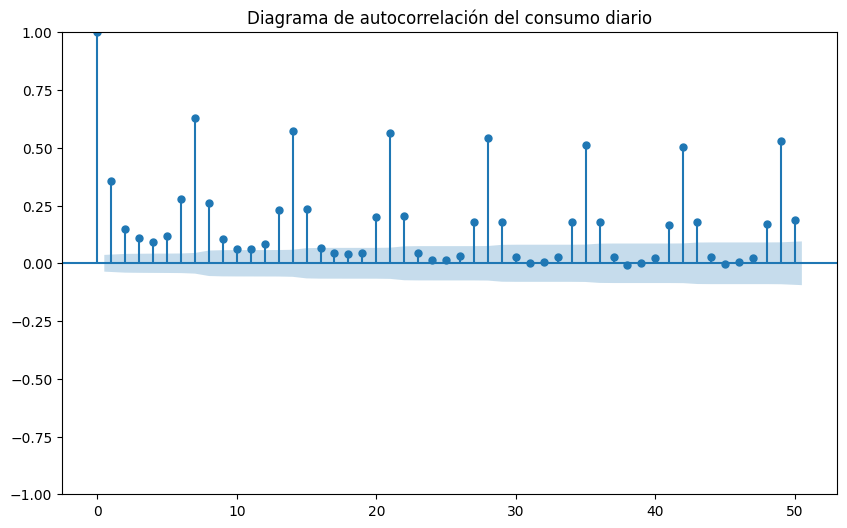

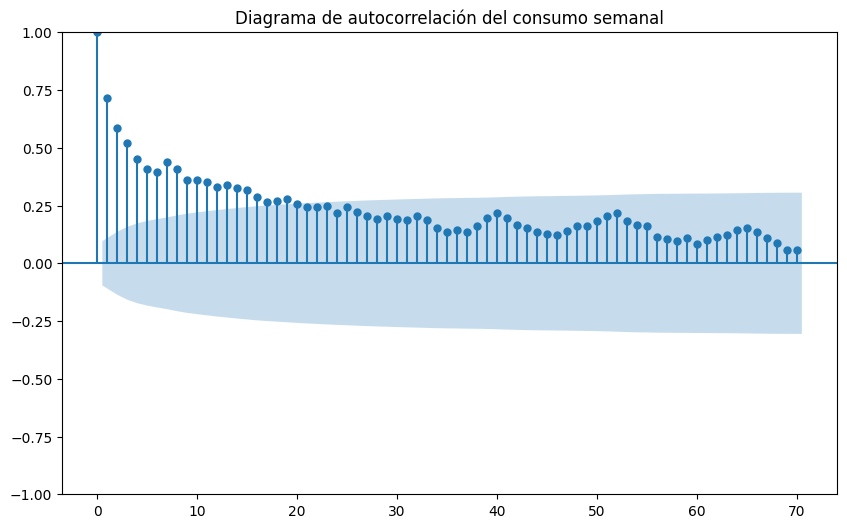

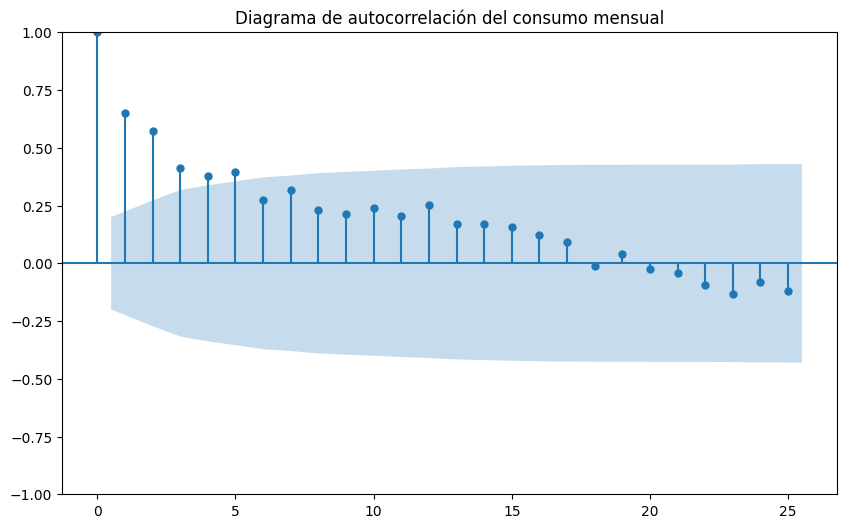

In [27]:
consumo_diario_zamora = serie_zamora.resample('D').sum()
comsumo_semanal_zamora = serie_zamora.resample('W').sum()
consumo_mensual_zamora = serie_zamora.resample('ME').sum()

fig, ax = plt.subplots(figsize = (10,6))
plot_acf(consumo_diario_zamora, lags = 50, ax = ax)
title = 'Diagrama de autocorrelación del consumo diario'
ax.set_title(title)
plt.show()


fig, ax = plt.subplots(figsize = (10,6))
plot_acf(consumo_semanal_zamora, lags = 70, ax = ax)
title = 'Diagrama de autocorrelación del consumo semanal'
ax.set_title(title)
plt.show()


fig, ax = plt.subplots(figsize = (10,6))
plot_acf(consumo_mensual_zamora, lags = 25, ax = ax)
title = 'Diagrama de autocorrelación del consumo mensual'
ax.set_title(title)
plt.show()

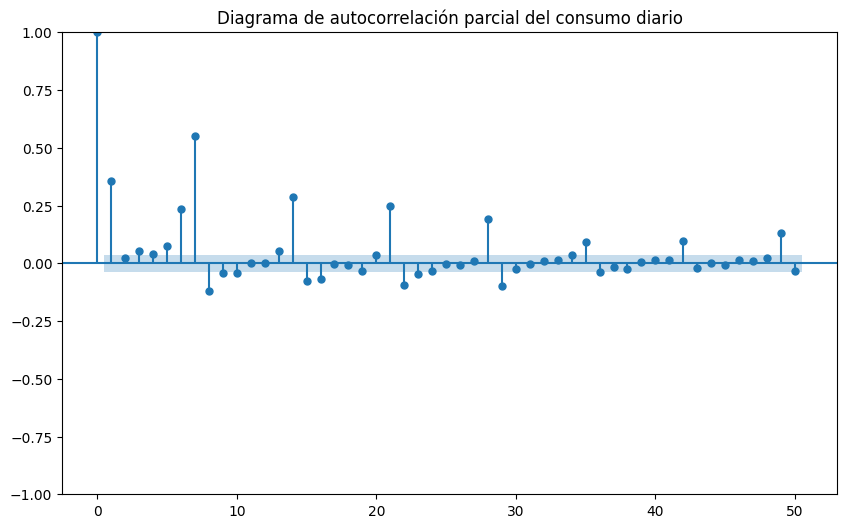

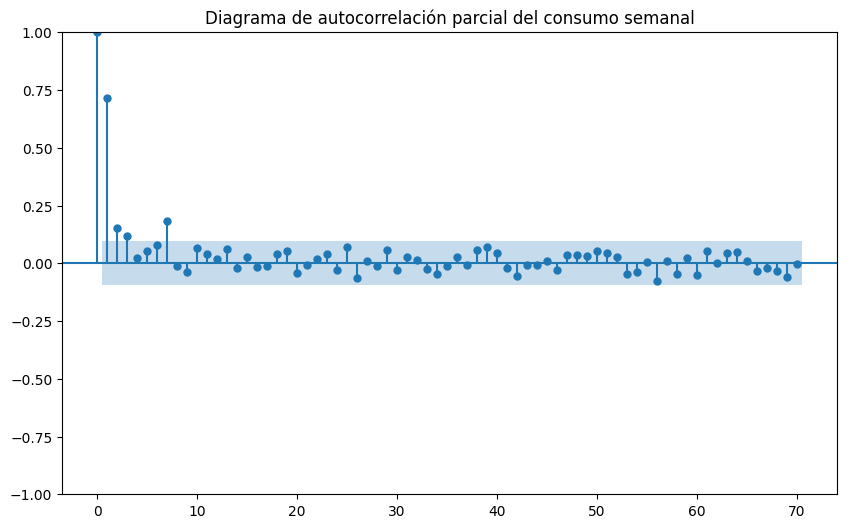

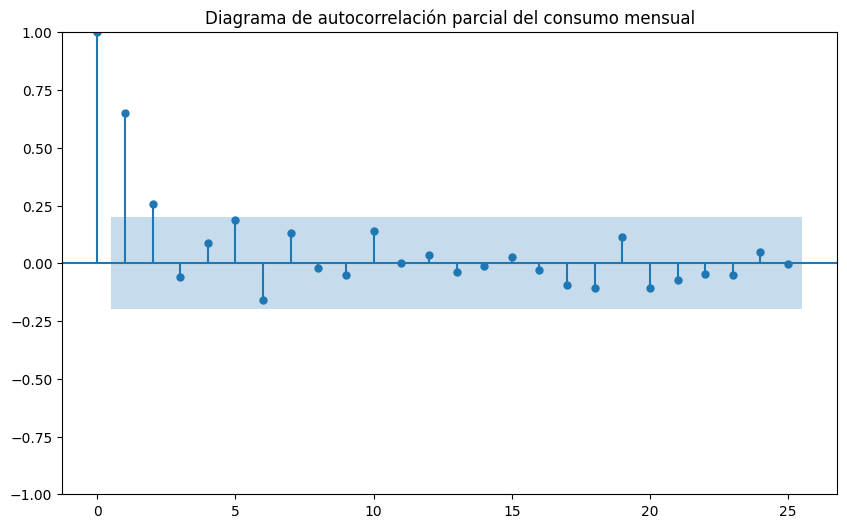

In [28]:
consumo_diario_zamora = serie_zamora.resample('D').sum()
comsumo_semanal_zamora = serie_zamora.resample('W').sum()
consumo_mensual_zamora = serie_zamora.resample('ME').sum()

fig, ax = plt.subplots(figsize = (10,6))
plot_pacf(consumo_diario_zamora, lags = 50, ax = ax)
title = 'Diagrama de autocorrelación parcial del consumo diario'
ax.set_title(title)
plt.show()



fig, ax = plt.subplots(figsize = (10,6))
plot_pacf(consumo_semanal_zamora, lags = 70, ax = ax)
title = 'Diagrama de autocorrelación parcial del consumo semanal'
ax.set_title(title)
plt.show()


fig, ax = plt.subplots(figsize = (10,6))
plot_pacf(consumo_mensual_zamora, lags = 25, ax = ax)
title = 'Diagrama de autocorrelación parcial del consumo mensual'
ax.set_title(title)
plt.show()

### Visualizaciones de interes 2.0

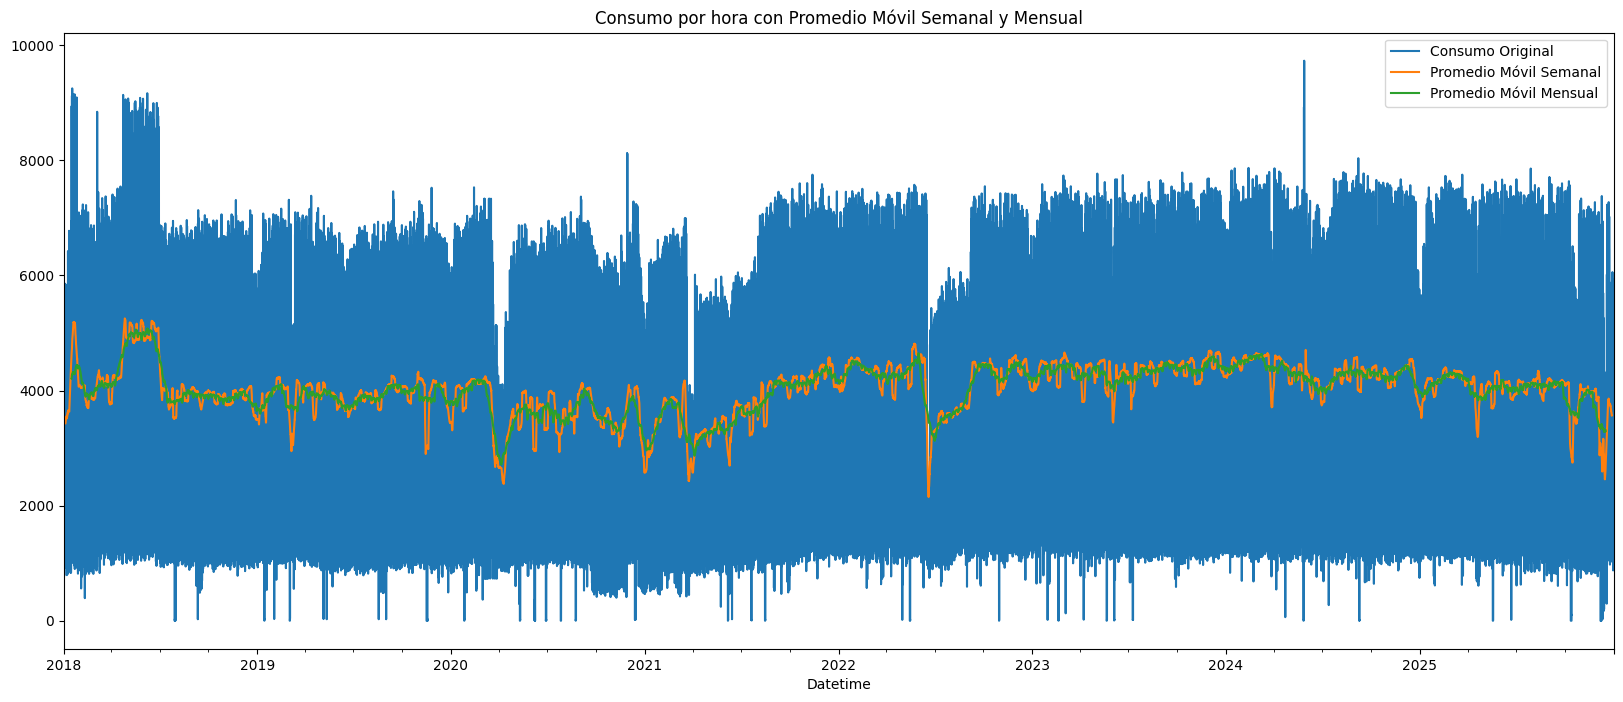

In [29]:
rolling_mean_semanal = serie_zamora.rolling(window=7*24, center=True).mean() # Ventana Semanal (7 días * 24 horas)
rolling_mean_mesual = serie_zamora.rolling(window=30*24, center=True).mean() # Ventana Mensual (30 días * 24 horas)


# Crear un DataFrame para plotear tanto la serie original como el promedio móvil
df_plot_rolling = pd.DataFrame({
    'Consumo Original': serie_zamora,
    'Promedio Móvil Semanal': rolling_mean_semanal,
    'Promedio Móvil Mensual': rolling_mean_mesual
})

df_plot_rolling.plot(title='Consumo por hora con Promedio Móvil Semanal y Mensual', figsize=(20, 8))
plt.show()

### Graficas de Estacionalidad

#### 1. Estacionalidad Mensual

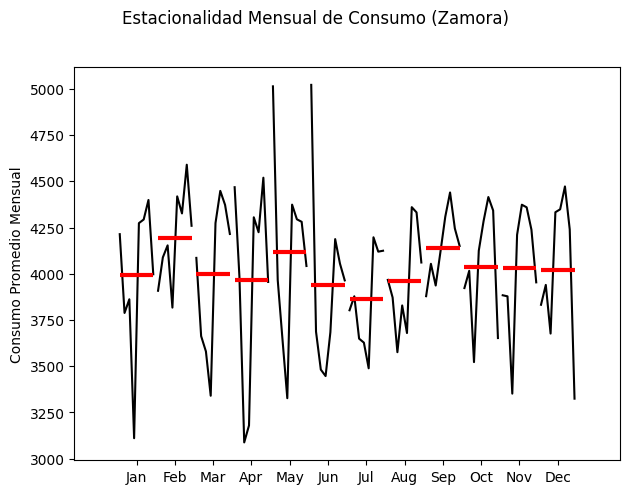

In [30]:
# Resample a promedio mensual y luego plotear
fig_month = month_plot(serie_zamora.resample('ME').mean(), ylabel='Consumo Promedio Mensual')
fig_month.suptitle('Estacionalidad Mensual de Consumo (Zamora)', y=1.02)
plt.tight_layout()
plt.show()

#### 2. Estacionalidad Trimestral

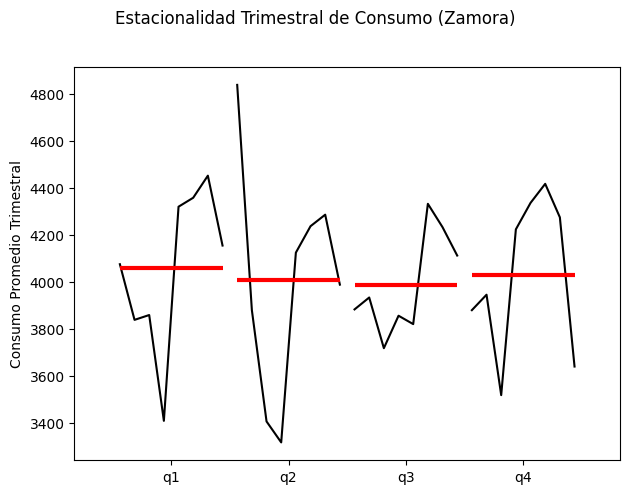

In [31]:
# Resample a promedio trimestral (inicio del trimestre) y luego plotear
fig_quarter = quarter_plot(serie_zamora.resample('QS').mean(), ylabel='Consumo Promedio Trimestral')
fig_quarter.suptitle('Estacionalidad Trimestral de Consumo (Zamora)', y=1.02)
plt.tight_layout()
plt.show()

#### 3. Estacionalidad Semanal

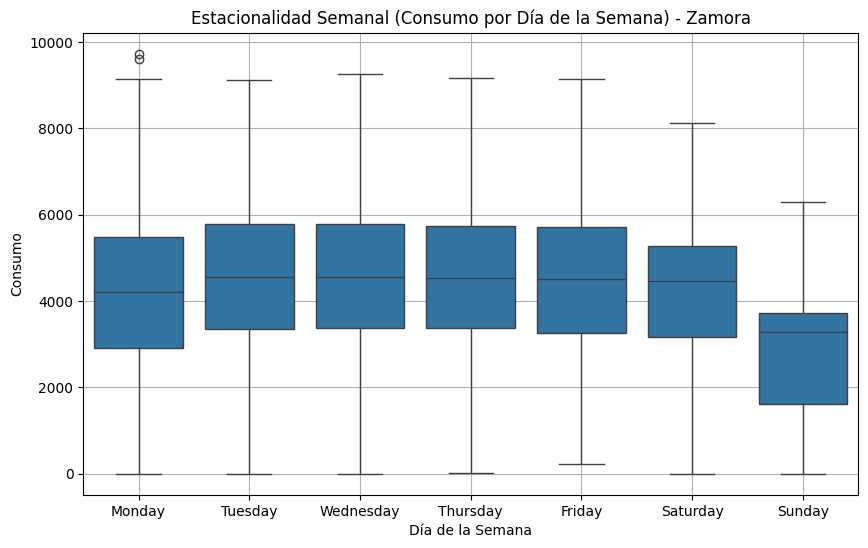

In [32]:
# Convertir la serie a DataFrame para facilitar la extracción de componentes de tiempo
df_temp = serie_zamora.copy().to_frame(name='Consumo')
df_temp['Dia_Semana'] = df_temp.index.day_name()
df_temp['Hora_Dia'] = df_temp.index.hour

# 3. Estacionalidad semanal (por día de la semana)
plt.figure(figsize=(10, 6))
sns.boxplot(x='Dia_Semana', y='Consumo', data=df_temp, order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
plt.title('Estacionalidad Semanal (Consumo por Día de la Semana) - Zamora')
plt.xlabel('Día de la Semana')
plt.ylabel('Consumo')
plt.grid(True)
plt.show()

#### 4. Estacionalidad diaria

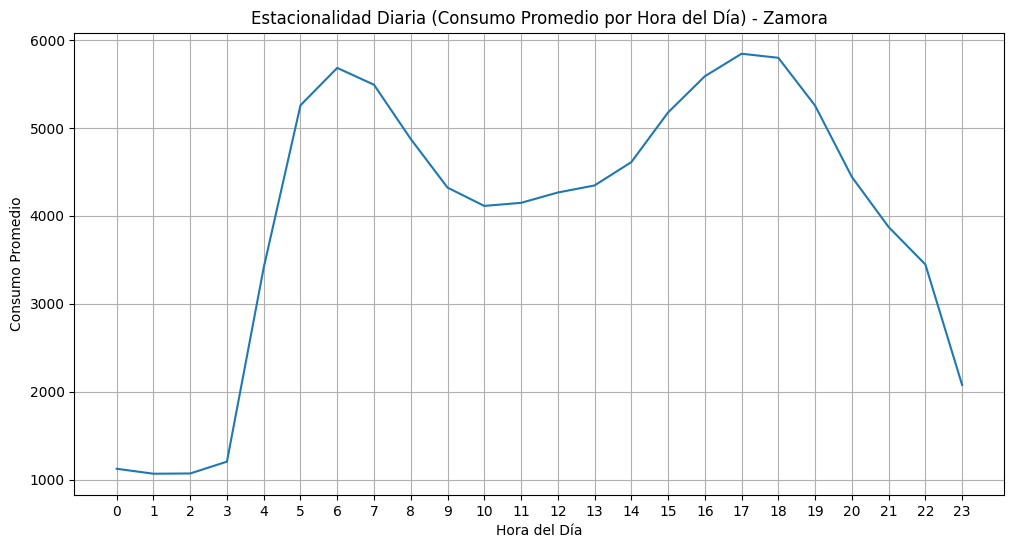

In [33]:
plt.figure(figsize=(12, 6))
sns.lineplot(x='Hora_Dia', y='Consumo', data=df_temp, estimator=np.mean, errorbar=None)
plt.title('Estacionalidad Diaria (Consumo Promedio por Hora del Día) - Zamora')
plt.xlabel('Hora del Día')
plt.ylabel('Consumo Promedio')
plt.xticks(range(24))
plt.grid(True)
plt.show()

### Descomposicion Estacional

Tarea

In [34]:
# Code

## Visualizaciones Multi-Serie

### Análisis multi-serie

#### Consumo por periodicidad Semanal

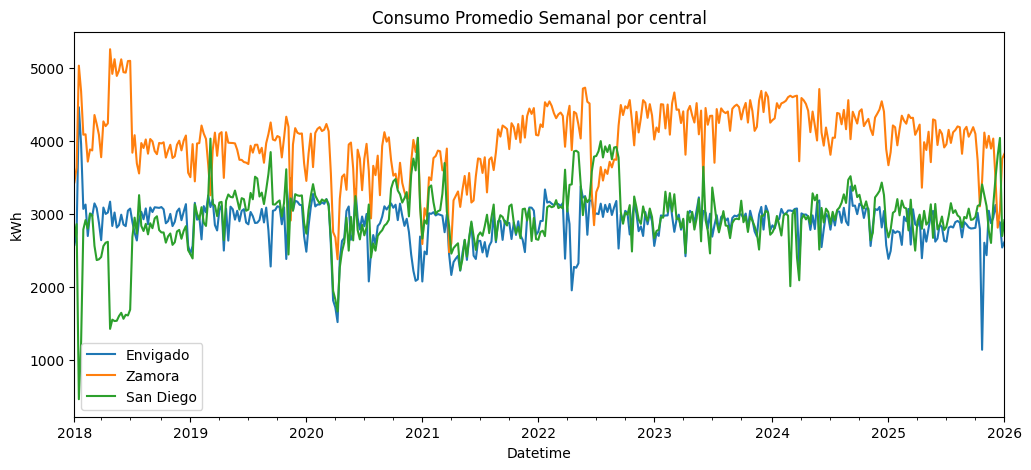

In [35]:
# ---- elegir periodicidad ----
periodicidad = "W"   # "H"=hora, "D"=día, "W"=semana, "ME"=mes

# ---- juntar series ----
df = pd.concat(
    [serie_envigado, serie_zamora, serie_sandiego],
    axis=1
)

df.columns = ["Envigado", "Zamora", "San Diego"]

# ---- re-muestrear ----
df_p = df.resample(periodicidad).mean()

# ---- gráfica ----
df_p.plot(figsize=(12,5))
plt.title("Consumo Promedio Semanal por central")
plt.ylabel("kWh")
plt.show()



#### Consumo por periodicidad Mensual

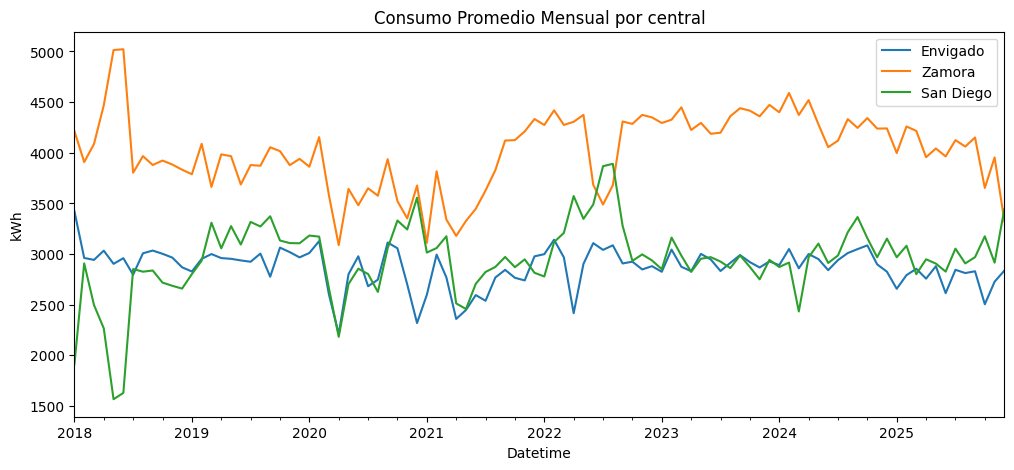

In [36]:
# ---- elegir periodicidad ----
periodicidad = "ME"   # "H"=hora, "D"=día, "W"=semana, "ME"=mes

# ---- juntar series ----
df = pd.concat(
    [serie_envigado, serie_zamora, serie_sandiego],
    axis=1
)

df.columns = ["Envigado", "Zamora", "San Diego"]

# ---- re-muestrear ----
df_p = df.resample(periodicidad).mean()

# ---- gráfica ----
df_p.plot(figsize=(12,5))
plt.title("Consumo Promedio Mensual por central")
plt.ylabel("kWh")
plt.show()

#### Consumo promedio mensual

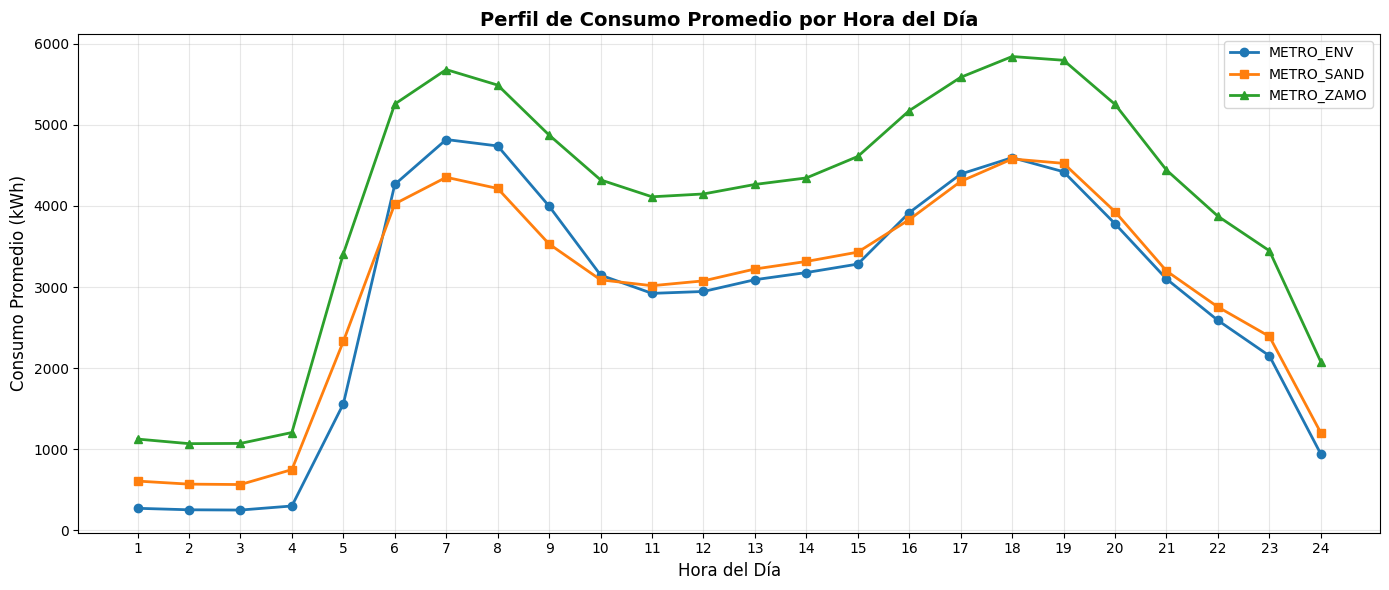

In [37]:
columnas_horas = [f'H{i}' for i in range(1, 25)]
consumo_promedio_hora_env = df_env[columnas_horas].mean()
consumo_promedio_hora_sand = df_sand[columnas_horas].mean()
consumo_promedio_hora_zamo = df_zamo[columnas_horas].mean()

fig, ax = plt.subplots(figsize=(14, 6))
horas = range(1, 25)

ax.plot(horas, consumo_promedio_hora_env, marker='o', label='METRO_ENV', linewidth=2)
ax.plot(horas, consumo_promedio_hora_sand, marker='s', label='METRO_SAND', linewidth=2)
ax.plot(horas, consumo_promedio_hora_zamo, marker='^', label='METRO_ZAMO', linewidth=2)

ax.set_title('Perfil de Consumo Promedio por Hora del Día', fontsize=14, fontweight='bold')
ax.set_xlabel('Hora del Día', fontsize=12)
ax.set_ylabel('Consumo Promedio (kWh)', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xticks(range(1, 25))

plt.tight_layout()
plt.show()

#### Participacion porcentual mensual acumulada

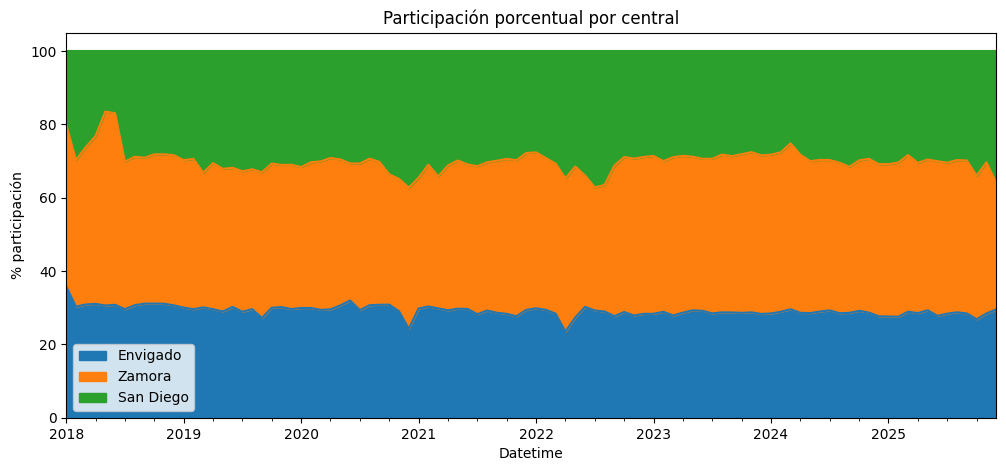

In [38]:
periodicidad = "ME"   # cambiar aquí


df.columns = ["Envigado", "Zamora", "San Diego"]

df_p = df.resample(periodicidad).sum()

# porcentaje
df_pct = df_p.div(df_p.sum(axis=1), axis=0) * 100

# gráfica
df_pct.plot.area(figsize=(12,5))
plt.title("Participación porcentual por central")
plt.ylabel("% participación")
plt.show()


#### Consumo total semanal acumulado

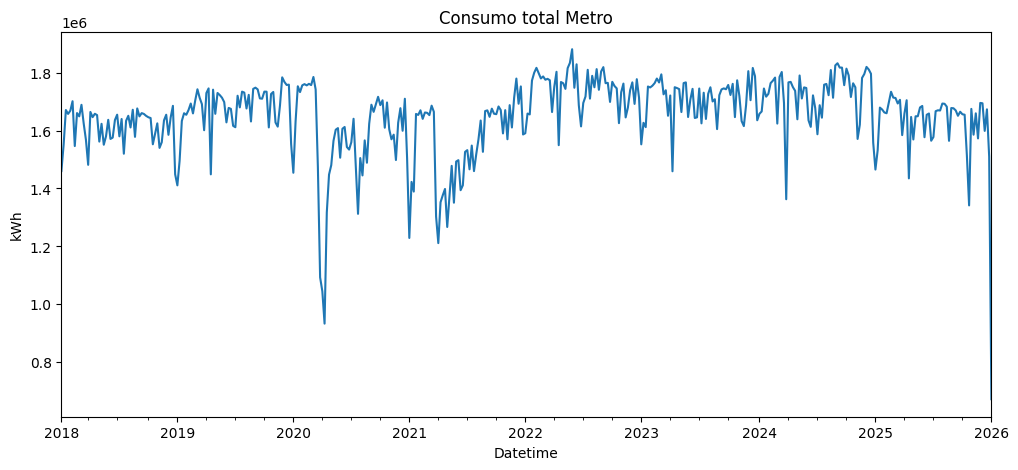

In [39]:
periodicidad = "W"

df_total = (
    serie_envigado +
    serie_zamora +
    serie_sandiego
)

df_total_p = df_total.resample(periodicidad).sum()

df_total_p.plot(figsize=(12,5))
plt.title("Consumo total Metro")
plt.ylabel("kWh")
plt.show()

#### Estacionalidad Semanal

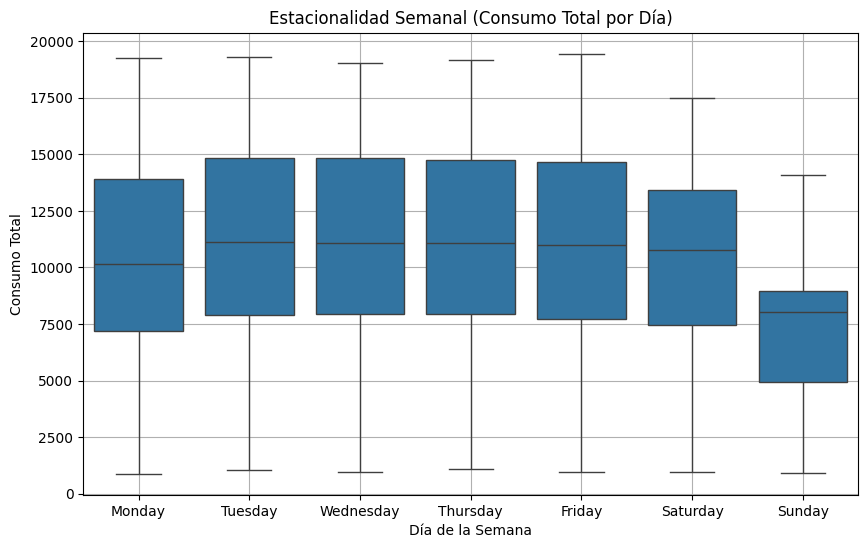

In [40]:
# --- Serie total (suma) ---
serie_total = df.sum(axis=1)

# --- Convertir a DataFrame temporal ---
df_temp = serie_total.to_frame(name="Consumo")

df_temp["Dia_Semana"] = df_temp.index.day_name()
df_temp["Hora_Dia"] = df_temp.index.hour

# --- Orden correcto ---
orden = [
    "Monday","Tuesday","Wednesday",
    "Thursday","Friday","Saturday","Sunday"
]

# --- Boxplot estilo presentación ---
plt.figure(figsize=(10,6))

sns.boxplot(
    x="Dia_Semana",
    y="Consumo",
    data=df_temp,
    order=orden
)

plt.title("Estacionalidad Semanal (Consumo Total por Día)")
plt.xlabel("Día de la Semana")
plt.ylabel("Consumo Total")
plt.grid(True)

plt.show()

#### Autocorrelacion promedio diario en la serie completa

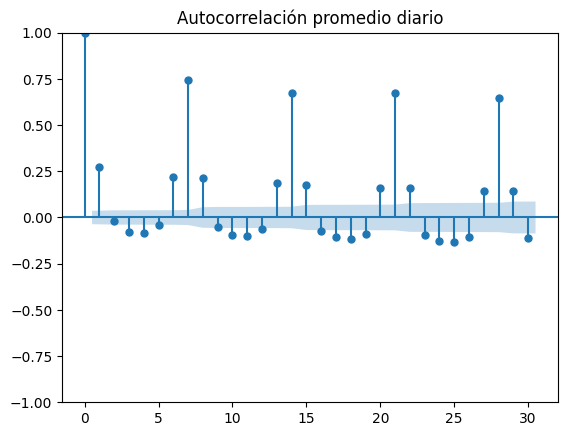

In [41]:
periodicidad = "D"
lags = 30   # ← cantidad de rezagos que quieres ver

df = pd.concat(
    [serie_envigado, serie_zamora, serie_sandiego],
    axis=1
)

df_total = df.sum(axis=1)

serie_p = df_total.resample(periodicidad).mean()

plot_acf(serie_p, lags=lags)

plt.title("Autocorrelación promedio diario")
plt.show()

#### Autocorrelacion acumulado diario en la serie completa

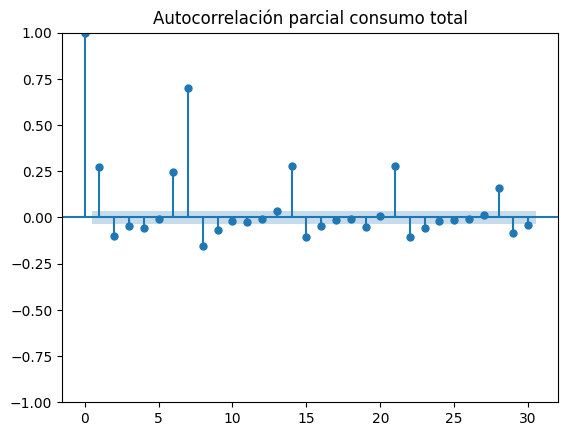

In [42]:
# ---- parámetros ----
periodicidad = "D"
lags = 30

# ---- unir centrales ----
df = pd.concat(
    [serie_envigado, serie_zamora, serie_sandiego],
    axis=1
)

# ---- serie total ----
df_total = df.sum(axis=1)

serie_p = df_total.resample(periodicidad).sum()

# ---- PACF ----
plot_pacf(
    serie_p,
    lags=lags,
    method="ywm"   # método estable
)

plt.title("Autocorrelación parcial consumo total")
plt.show()


### Diagrama de Calor
Una serie

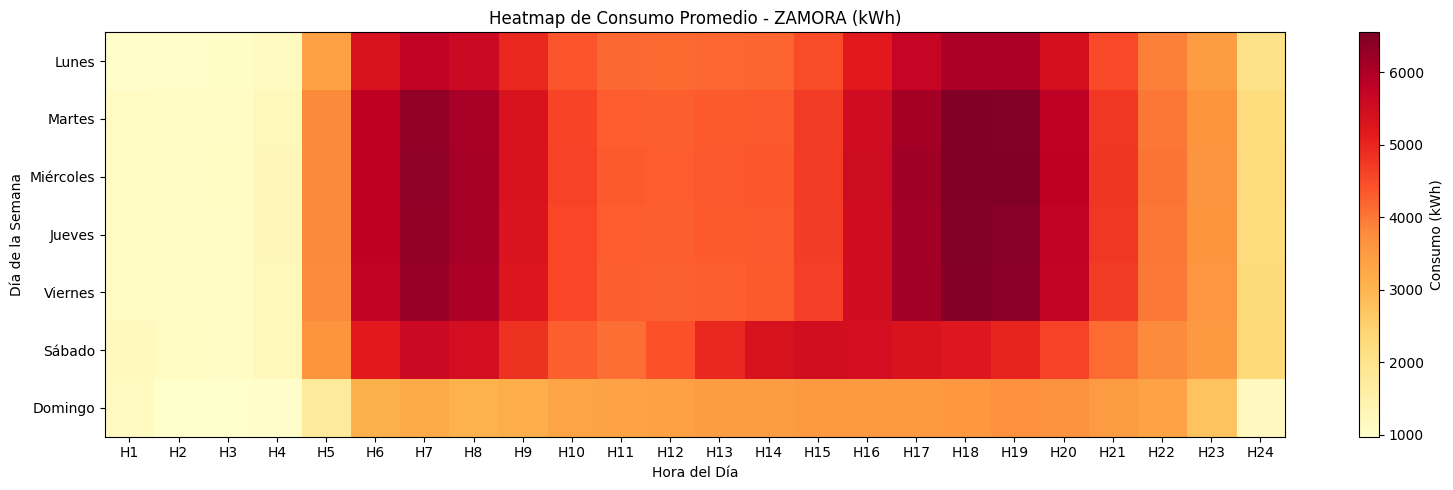

In [43]:
cols_horas = [f'H{i}' for i in range(1,25)]

# Asegurar fecha en formato datetime
df = df_zamo.copy()
df['Fecha'] = pd.to_datetime(df['Fecha'])

# Día de la semana (0=Lunes ... 6=Domingo)
df['dow'] = df['Fecha'].dt.dayofweek

# Promedio por día de semana
prom = df.groupby('dow')[cols_horas].mean()

# Orden y nombres bonitos
nombres = ['Lunes','Martes','Miércoles','Jueves','Viernes','Sábado','Domingo']
prom.index = [nombres[i] for i in prom.index]
prom = prom.reindex(nombres)  # fuerza orden Lunes..Domingo

# Heatmap
plt.figure(figsize=(16,5))
plt.imshow(prom.values, aspect='auto', origin='upper', cmap='YlOrRd')
plt.colorbar(label='Consumo (kWh)')
plt.xticks(range(24), cols_horas, rotation=0)
plt.yticks(range(7), nombres)
plt.xlabel('Hora del Día')
plt.ylabel('Día de la Semana')
plt.title('Heatmap de Consumo Promedio - ZAMORA (kWh)')
plt.tight_layout()
plt.show()

Multi-Serie

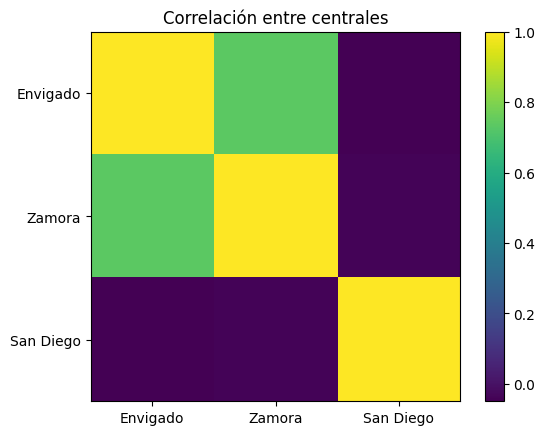

In [44]:
periodicidad = "YE"

df = pd.concat(
    [serie_envigado, serie_zamora, serie_sandiego],
    axis=1
)

df.columns = ["Envigado", "Zamora", "San Diego"]

df_p = df.resample(periodicidad).mean()

corr = df_p.corr()

plt.imshow(corr)
plt.colorbar()
plt.xticks(range(3), corr.columns)
plt.yticks(range(3), corr.columns)
plt.title("Correlación entre centrales")
plt.show()
